In [1]:
import pandas as pd
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
anime_path = kagglehub.dataset_download("CooperUnion/anime-recommendations-database")

print("Path to dataset files:", anime_path)

100%|██████████| 25.0M/25.0M [00:01<00:00, 18.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/CooperUnion/anime-recommendations-database/versions/1


In [3]:
game_path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", game_path)

100%|██████████| 381k/381k [00:00<00:00, 982kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gregorut/videogamesales/versions/2


In [4]:
print("Файлы в папке anime:")
print(os.listdir(anime_path))

print("Файлы в папке game:")
print(os.listdir(game_path))

Файлы в папке anime:
['rating.csv', 'anime.csv']
Файлы в папке game:
['vgsales.csv']


In [5]:
anime = pd.read_csv(os.path.join(anime_path, 'anime.csv'))
print(f"Тип объекта: {type(anime)}")

game = pd.read_csv(os.path.join(game_path, 'vgsales.csv'))
print(f"Тип объекта: {type(game)}")

Тип объекта: <class 'pandas.core.frame.DataFrame'>
Тип объекта: <class 'pandas.core.frame.DataFrame'>


In [6]:
print(anime.head())
print("="*80)
print(anime.tail())

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
       anime_id                                               name   genre  \
12289      9316       Toushindai My Lover: Minami tai Mecha-Minami  

In [7]:
print(game.head())
print("="*80)
print(game.tail())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
        Rank                                              Name Platform  \
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597   

In [8]:
print(f"Размерность: {anime.shape}")
print(f"Размерность: {game.shape}")

Размерность: (12294, 7)
Размерность: (16598, 11)


In [9]:
anime.info()
print("="*70)
game.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598

In [10]:
for col in anime.columns:
    dtype = anime[col].dtype
    example = anime[col].dropna().iloc[0]
    print(f"{col:20} | тип: {str(dtype):10} | пример значения: {example!r}")

anime_id             | тип: int64      | пример значения: np.int64(32281)
name                 | тип: object     | пример значения: 'Kimi no Na wa.'
genre                | тип: object     | пример значения: 'Drama, Romance, School, Supernatural'
type                 | тип: object     | пример значения: 'Movie'
episodes             | тип: object     | пример значения: '1'
rating               | тип: float64    | пример значения: np.float64(9.37)
members              | тип: int64      | пример значения: np.int64(200630)


колонка `episodes` не соответсвует числовому типу, а определяется как `object`

In [11]:
for col in game.columns:
    dtype = game[col].dtype
    example = game[col].dropna().iloc[0]
    print(f"{col:20} | тип: {str(dtype):10} | пример значения: {example!r}")

Rank                 | тип: int64      | пример значения: np.int64(1)
Name                 | тип: object     | пример значения: 'Wii Sports'
Platform             | тип: object     | пример значения: 'Wii'
Year                 | тип: float64    | пример значения: np.float64(2006.0)
Genre                | тип: object     | пример значения: 'Sports'
Publisher            | тип: object     | пример значения: 'Nintendo'
NA_Sales             | тип: float64    | пример значения: np.float64(41.49)
EU_Sales             | тип: float64    | пример значения: np.float64(29.02)
JP_Sales             | тип: float64    | пример значения: np.float64(3.77)
Other_Sales          | тип: float64    | пример значения: np.float64(8.46)
Global_Sales         | тип: float64    | пример значения: np.float64(82.74)


In [12]:
numeric_cols_A = anime.select_dtypes(include=['int64', 'float64']).columns
print("Числовые колонки:", list(numeric_cols_A))

anime[numeric_cols_A].describe()

Числовые колонки: ['anime_id', 'rating', 'members']


,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [13]:
numeric_cols_B = game.select_dtypes(include=['int64', 'float64']).columns
print("Числовые колонки:", list(numeric_cols_B))

game[numeric_cols_B].describe()

Числовые колонки: ['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [37]:
cat_cols = anime.select_dtypes(include=['object']).columns
print("Категориальные колонки:", list(cat_cols))

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Уник: {anime[col].nunique()}")
    print(f"Мода: {anime[col].mode().values[0] if not anime[col].mode().empty else 'нет'}")

from collections import Counter

all_genres = anime['genre'].dropna().str.split(', ').explode()

genre_counts = all_genres.value_counts()

print(f"\nВсего уникальных жанров: {genre_counts.shape[0]}")
print(f"\nТоп-15 жанров:")
print(genre_counts.head(15))

Категориальные колонки: ['name', 'genre', 'type', 'episodes']

--- name ---
Уник: 12015
Мода: Saru Kani Gassen

--- genre ---
Уник: 3229
Мода: Hentai

--- type ---
Уник: 6
Мода: TV

--- episodes ---
Уник: 187
Мода: 1

Всего уникальных жанров: 43

Топ-15 жанров:
genre
Comedy           4575
Action           2768
Adventure        2316
Fantasy          2242
Sci-Fi           2036
Drama            1977
Shounen          1684
Kids             1598
Romance          1437
Slice of Life    1204
School           1176
Hentai           1133
Supernatural     1001
Mecha             929
Music             842
Name: count, dtype: int64


In [15]:
cat_cols = game.select_dtypes(include=['object']).columns
print("Категориальные колонки:", list(cat_cols))

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"Уник: {game[col].nunique()}")
    print(f"Мода: {game[col].mode().values[0] if not game[col].mode().empty else 'нет'}")

Категориальные колонки: ['Name', 'Platform', 'Genre', 'Publisher']

--- Name ---
Уник: 11493
Мода: Need for Speed: Most Wanted

--- Platform ---
Уник: 31
Мода: DS

--- Genre ---
Уник: 12
Мода: Action

--- Publisher ---
Уник: 578
Мода: Electronic Arts


In [16]:
missing = anime.isnull().sum()

print("Колонки с пропусками:")
print(missing[missing > 0])

print(f"\nВсего пропусков: {anime.isnull().sum().sum()}")

Колонки с пропусками:
genre      62
type       25
rating    230
dtype: int64

Всего пропусков: 317


In [17]:
missing = game.isnull().sum()

print("Колонки с пропусками:")
print(missing[missing > 0])

print(f"\nВсего пропусков: {game.isnull().sum().sum()}")

Колонки с пропусками:
Year         271
Publisher     58
dtype: int64

Всего пропусков: 329


In [18]:
anime = anime.dropna()
print(f"Размерность: {anime.shape}")

game = game.dropna()
print(f"Размерность: {game.shape}")

Размерность: (12017, 7)
Размерность: (16291, 11)


In [19]:
total_duplicates = anime.duplicated().sum()
print(f"Полных дубликатов anime: {total_duplicates}")

total_duplicates = game.duplicated().sum()
print(f"Полных дубликатов game: {total_duplicates}")

Полных дубликатов anime: 0
Полных дубликатов game: 0


In [20]:
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

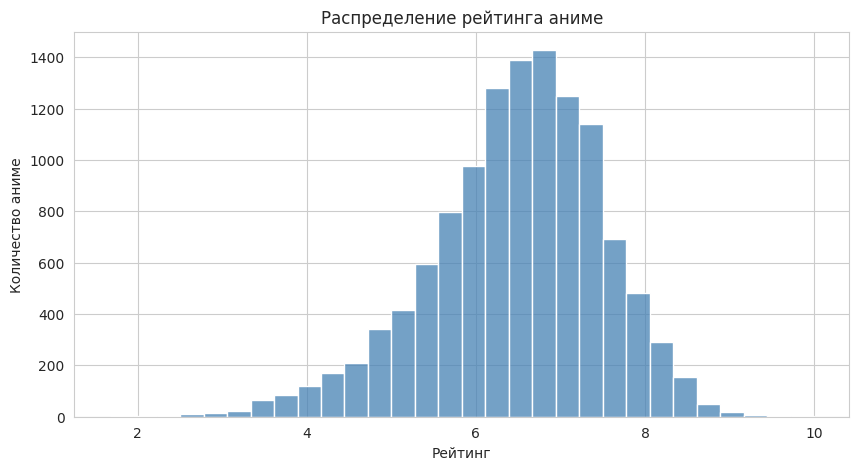

In [21]:
# ГИСТОГРАММА
plt.figure(figsize=(10, 5))

sns.histplot(data=anime, x='rating', bins=30, kde=False, color='steelblue')

plt.title('Распределение рейтинга аниме')
plt.xlabel('Рейтинг')
plt.ylabel('Количество аниме')
plt.show()

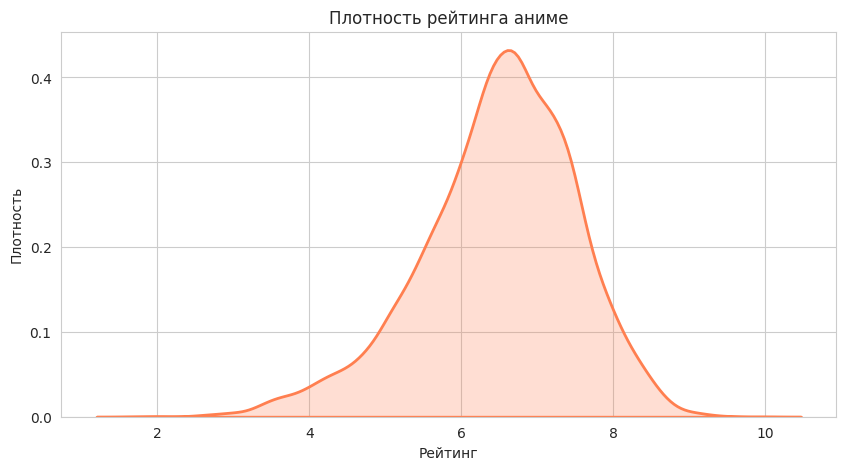

In [22]:
# ГРАФИК ПЛОТНОСТИ (KDE)
plt.figure(figsize=(10, 5))

sns.kdeplot(data=anime, x='rating', fill=True, color='coral', linewidth=2)

plt.title('Плотность рейтинга аниме')
plt.xlabel('Рейтинг')
plt.ylabel('Плотность')
plt.show()

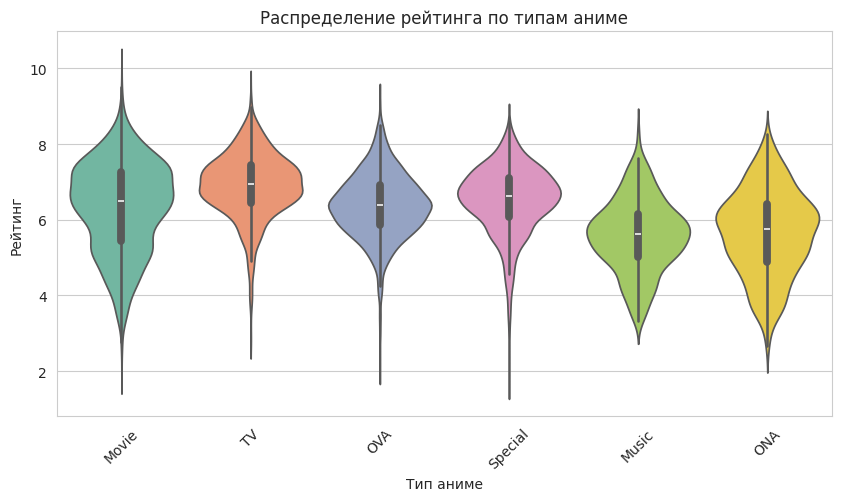

In [23]:
# СКРИПИЧНАЯ ДИАГРАММА
plt.figure(figsize=(10, 5))

sns.violinplot(data=anime, x='type', y='rating', hue='type', palette='Set2', legend=False)

plt.title('Распределение рейтинга по типам аниме')
plt.xlabel('Тип аниме')
plt.ylabel('Рейтинг')
plt.xticks(rotation=45)
plt.show()

## Визуальный анализ: Anime

### Распределение рейтинга
- **Гистограмма** (`histplot`): распределение близко к нормальному, пик в районе 6.5–7.5.
- **Плотность** (`kdeplot`): чётко видна скошенность влево — мало аниме с низким рейтингом.
- **Скрипичная** (`violinplot`) по типам: TV и Movie имеют более узкое распределение, ONA — шире.

**Вывод**: рейтинг — устойчивый признак, большинство аниме имеет рейтинг 6–7.5.

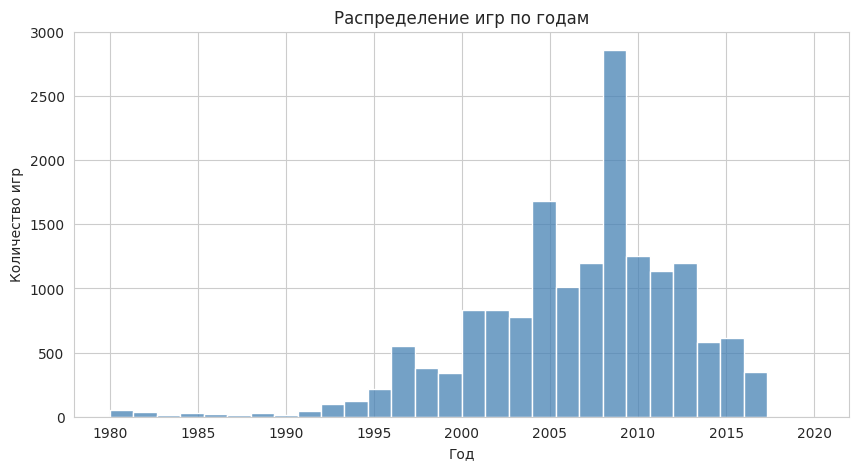

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(data=game, x='Year', bins=30, kde=False, color='steelblue')

plt.title('Распределение игр по годам')
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.show()

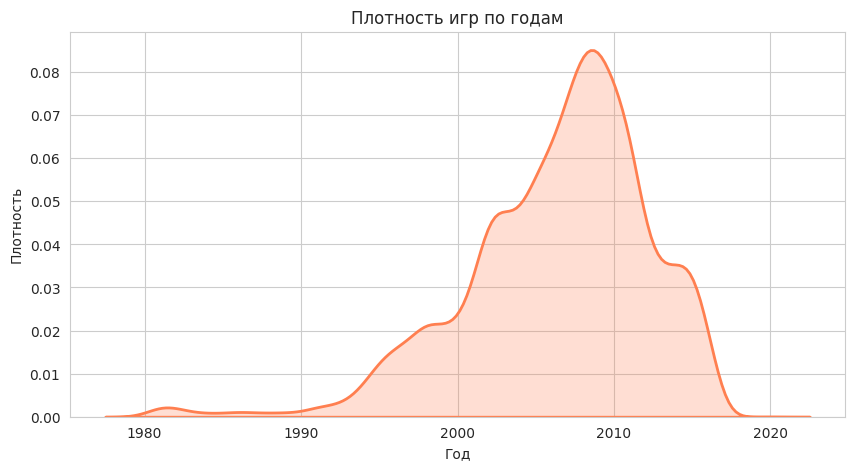

In [25]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=game, x='Year', fill=True, color='coral', linewidth=2)

plt.title('Плотность игр по годам')
plt.xlabel('Год')
plt.ylabel('Плотность')
plt.show()

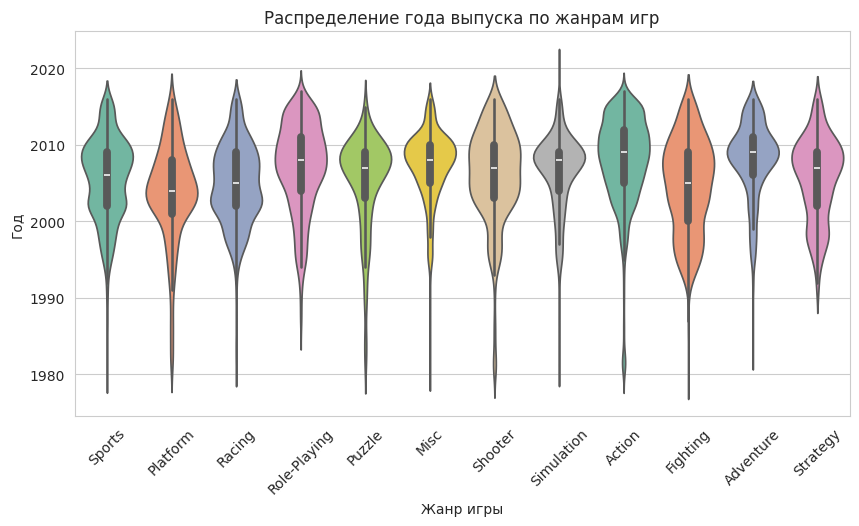

In [26]:
plt.figure(figsize=(10, 5))

sns.violinplot(data=game, x='Genre', y='Year', hue='Genre', palette='Set2', legend=False)

plt.title('Распределение года выпуска по жанрам игр')
plt.xlabel('Жанр игры')
plt.ylabel('Год')
plt.xticks(rotation=45)
plt.show()

## Визуальный анализ: Video Games Sales

### Распределение года выпуска
- **Гистограмма**: пик приходится на 2005–2010 гг.
- **Плотность**: видно, что до 1995 г. игр выпускалось мало.
- **Скрипичная** по жанрам: разные жанры имеют разную медиану года.

**Вывод**: рынок игр рос до 2010 года, затем начал снижаться (по данным датасета).

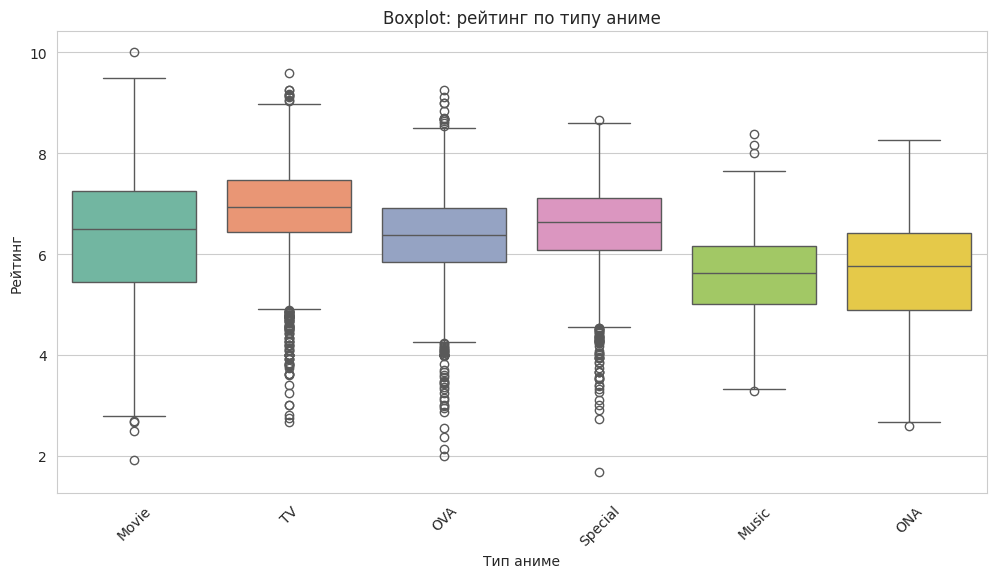

In [27]:
# BOXPLOT
plt.figure(figsize=(12, 6))

sns.boxplot(data=anime, x='type', y='rating', hue='type', palette='Set2', legend=False)

plt.title('Boxplot: рейтинг по типу аниме')
plt.xlabel('Тип аниме')
plt.ylabel('Рейтинг')
plt.xticks(rotation=45)
plt.show()

### Boxplot: поиск аномалий
- По `rating` — **мало** выбросов (значения ниже ~4 и выше ~9.3).
- По `members` — **очень много** выбросов (длинный правый хвост).
- По `episodes` — **много** выбросов (аниме с сотнями эпизодов).

**Вывод**: `rating` — «чистый» признак, `members` и `episodes` требуют логарифмирования.

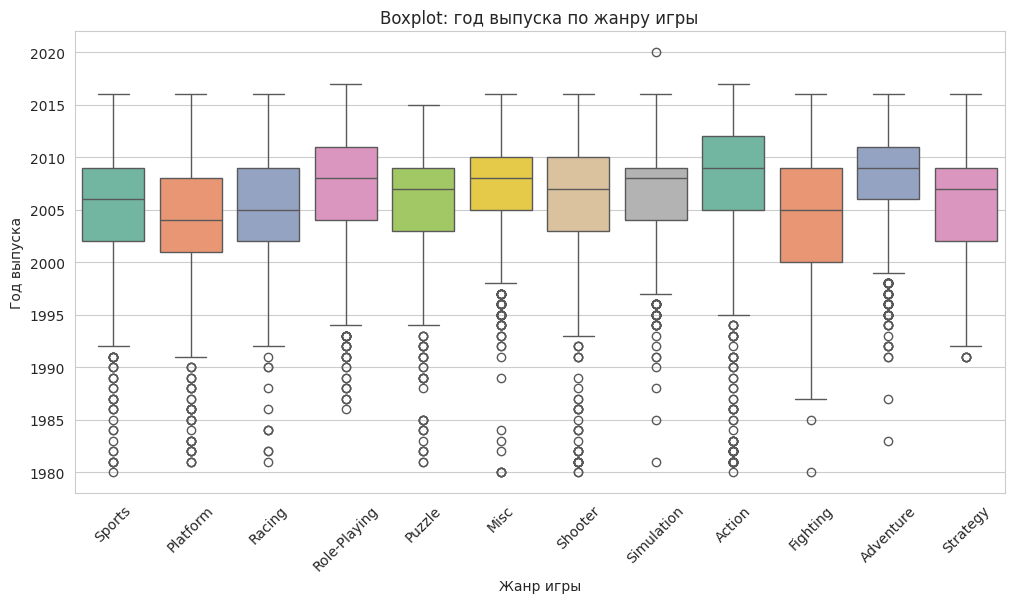

In [28]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=game, x='Genre', y='Year', hue='Genre', palette='Set2', legend=False)

plt.title('Boxplot: год выпуска по жанру игры')
plt.xlabel('Жанр игры')
plt.ylabel('Год выпуска')
plt.xticks(rotation=45)
plt.show()

### Boxplot: поиск аномалий
- По **всем** признакам продаж — **экстремально много** выбросов.
- `Global_Sales`: медиана ~0.17 млн, максимум — 82.74 млн (разрыв в 500 раз).
- `Year` — небольшое число выбросов.

**Вывод**: продажи подчиняются закону Парето (20% игр = 80% продаж).

In [29]:
corr_matrix_A = anime[numeric_cols_A].corr()

print(corr_matrix_A.round(3))

          anime_id  rating  members
anime_id     1.000  -0.281   -0.074
rating      -0.281   1.000    0.388
members     -0.074   0.388    1.000


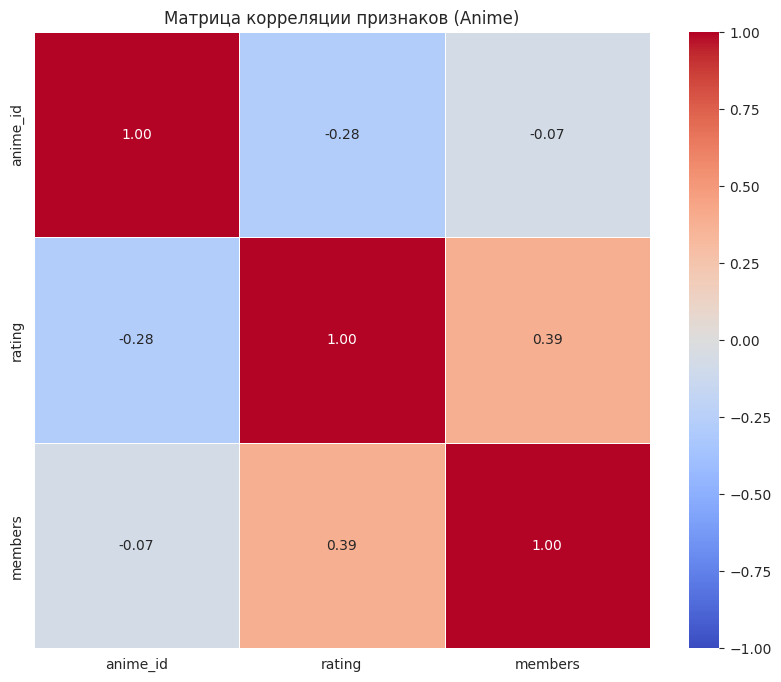

In [30]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix_A,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Матрица корреляции признаков (Anime)')
plt.show()

## Корреляционный анализ: Anime

### Тепловая карта корреляций
- Самая сильная связь: `rating` ↔ `members` = **0.39** (средняя прямая).
- `anime_id` ↔ `rating` = **−0.28** (слабая обратная).
- `anime_id` ↔ `members` = **−0.07** (нет связи).

### Scatterplot: rating vs members
- Видна слабая положительная тенденция: популярные аниме имеют рейтинг выше.
- Разброс большой — связь не линейная, а скорее неявная.

**Вывод**: популярность (members) частично предсказывает рейтинг, но не полностью.

In [31]:
corr_matrix_B = game[numeric_cols_B].corr()

print(corr_matrix_B.round(3))

               Rank   Year  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
Rank          1.000  0.178    -0.400    -0.379    -0.269       -0.333   
Year          0.178  1.000    -0.091     0.006    -0.169        0.041   
NA_Sales     -0.400 -0.091     1.000     0.769     0.451        0.635   
EU_Sales     -0.379  0.006     0.769     1.000     0.436        0.726   
JP_Sales     -0.269 -0.169     0.451     0.436     1.000        0.291   
Other_Sales  -0.333  0.041     0.635     0.726     0.291        1.000   
Global_Sales -0.427 -0.075     0.941     0.903     0.613        0.748   

              Global_Sales  
Rank                -0.427  
Year                -0.075  
NA_Sales             0.941  
EU_Sales             0.903  
JP_Sales             0.613  
Other_Sales          0.748  
Global_Sales         1.000  


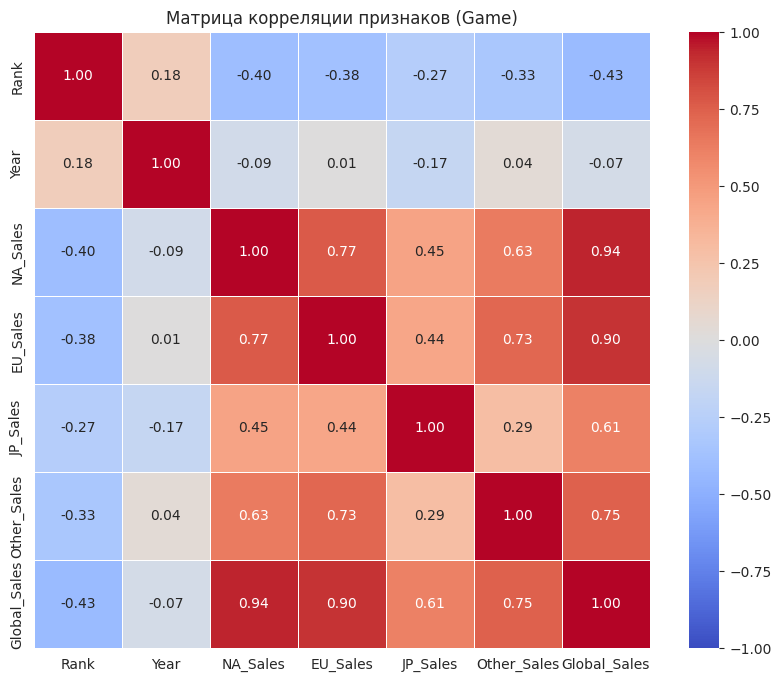

In [32]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix_B,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Матрица корреляции признаков (Game)')
plt.show()

## Корреляционный анализ: Video Games Sales

### Тепловая карта корреляций
Очень сильные связи:
- `NA_Sales` ↔ `Global_Sales` = **0.94**
- `EU_Sales` ↔ `Global_Sales` = **0.90**
- `Other_Sales` ↔ `Global_Sales` = **0.75**
- `JP_Sales` ↔ `Global_Sales` = **0.61**
- `NA_Sales` ↔ `EU_Sales` = **0.77**

Обратная связь:
- `Rank` ↔ `Global_Sales` = **−0.43**

### Scatterplot: Other_Sales vs Global_Sales
- Чёткая линейная связь: чем больше продажи в других регионах, тем больше глобальные.

**Вывод**: региональные продажи сильно коррелируют с глобальными. NA и EU — крупнейшие рынки.

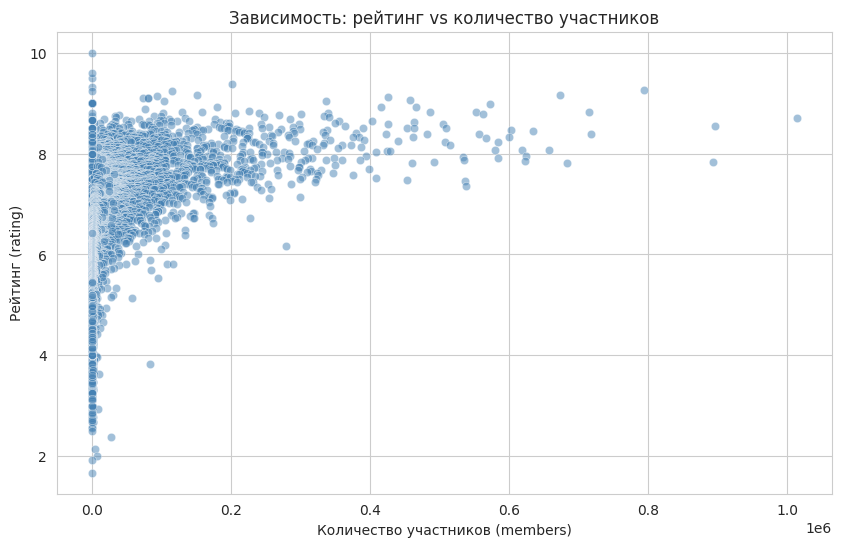

In [33]:
# SCATTERPLOT: rating vs members
plt.figure(figsize=(10, 6))

sns.scatterplot(data=anime, x='members', y='rating', alpha=0.5, color='steelblue')

plt.title('Зависимость: рейтинг vs количество участников')
plt.xlabel('Количество участников (members)')
plt.ylabel('Рейтинг (rating)')
plt.show()

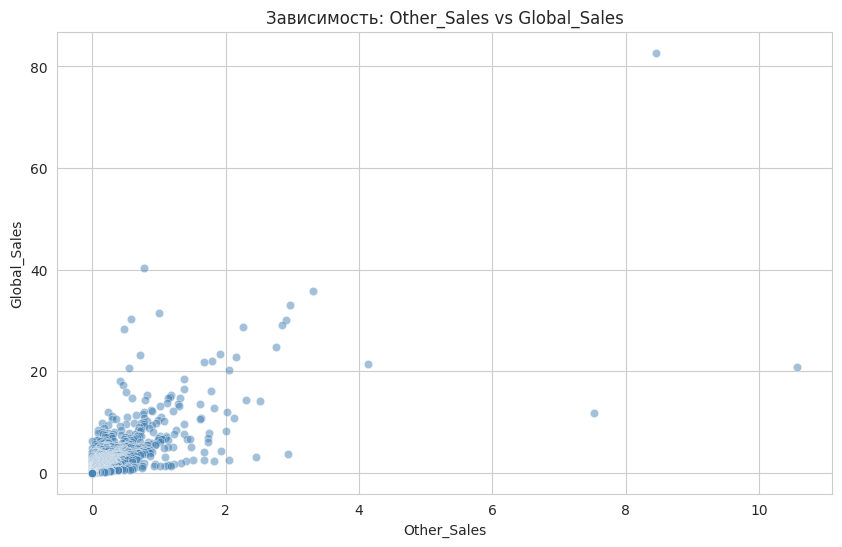

In [34]:
# SCATTERPLOT: Other_Sales vs Global_Sales
plt.figure(figsize=(10, 6))

sns.scatterplot(data=game, x='Other_Sales', y='Global_Sales', alpha=0.5, color='steelblue')

plt.title('Зависимость: Other_Sales vs Global_Sales')
plt.xlabel('Other_Sales')
plt.ylabel('Global_Sales')
plt.show()

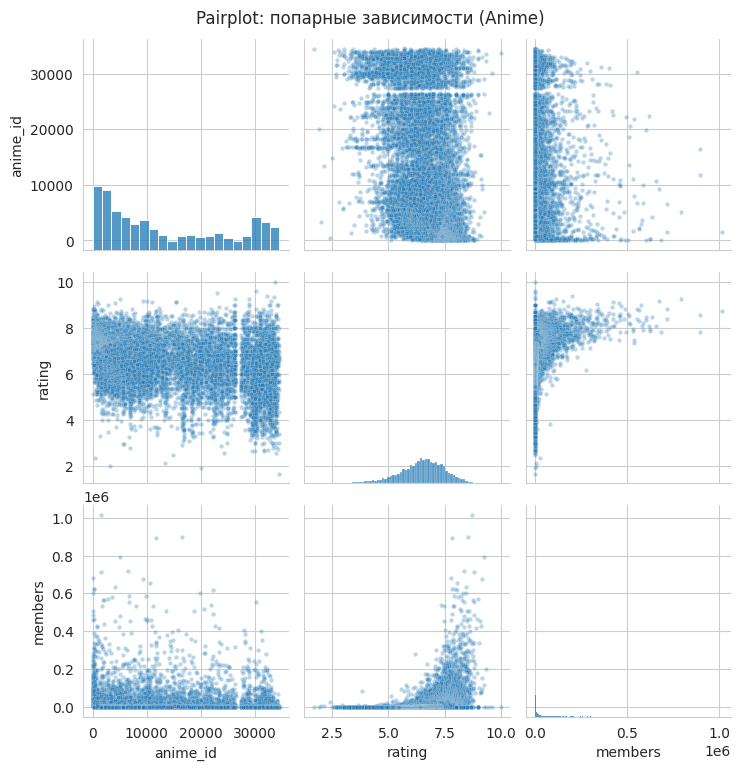

In [35]:
# PAIRPLOT ДЛЯ ВСЕХ ЧИСЛОВЫХ ПРИЗНАКОВ
sns.pairplot(anime[numeric_cols_A],
             diag_kind='hist',
             plot_kws={'alpha': 0.3, 's': 10})

plt.suptitle('Pairplot: попарные зависимости (Anime)', y=1.02)
plt.show()

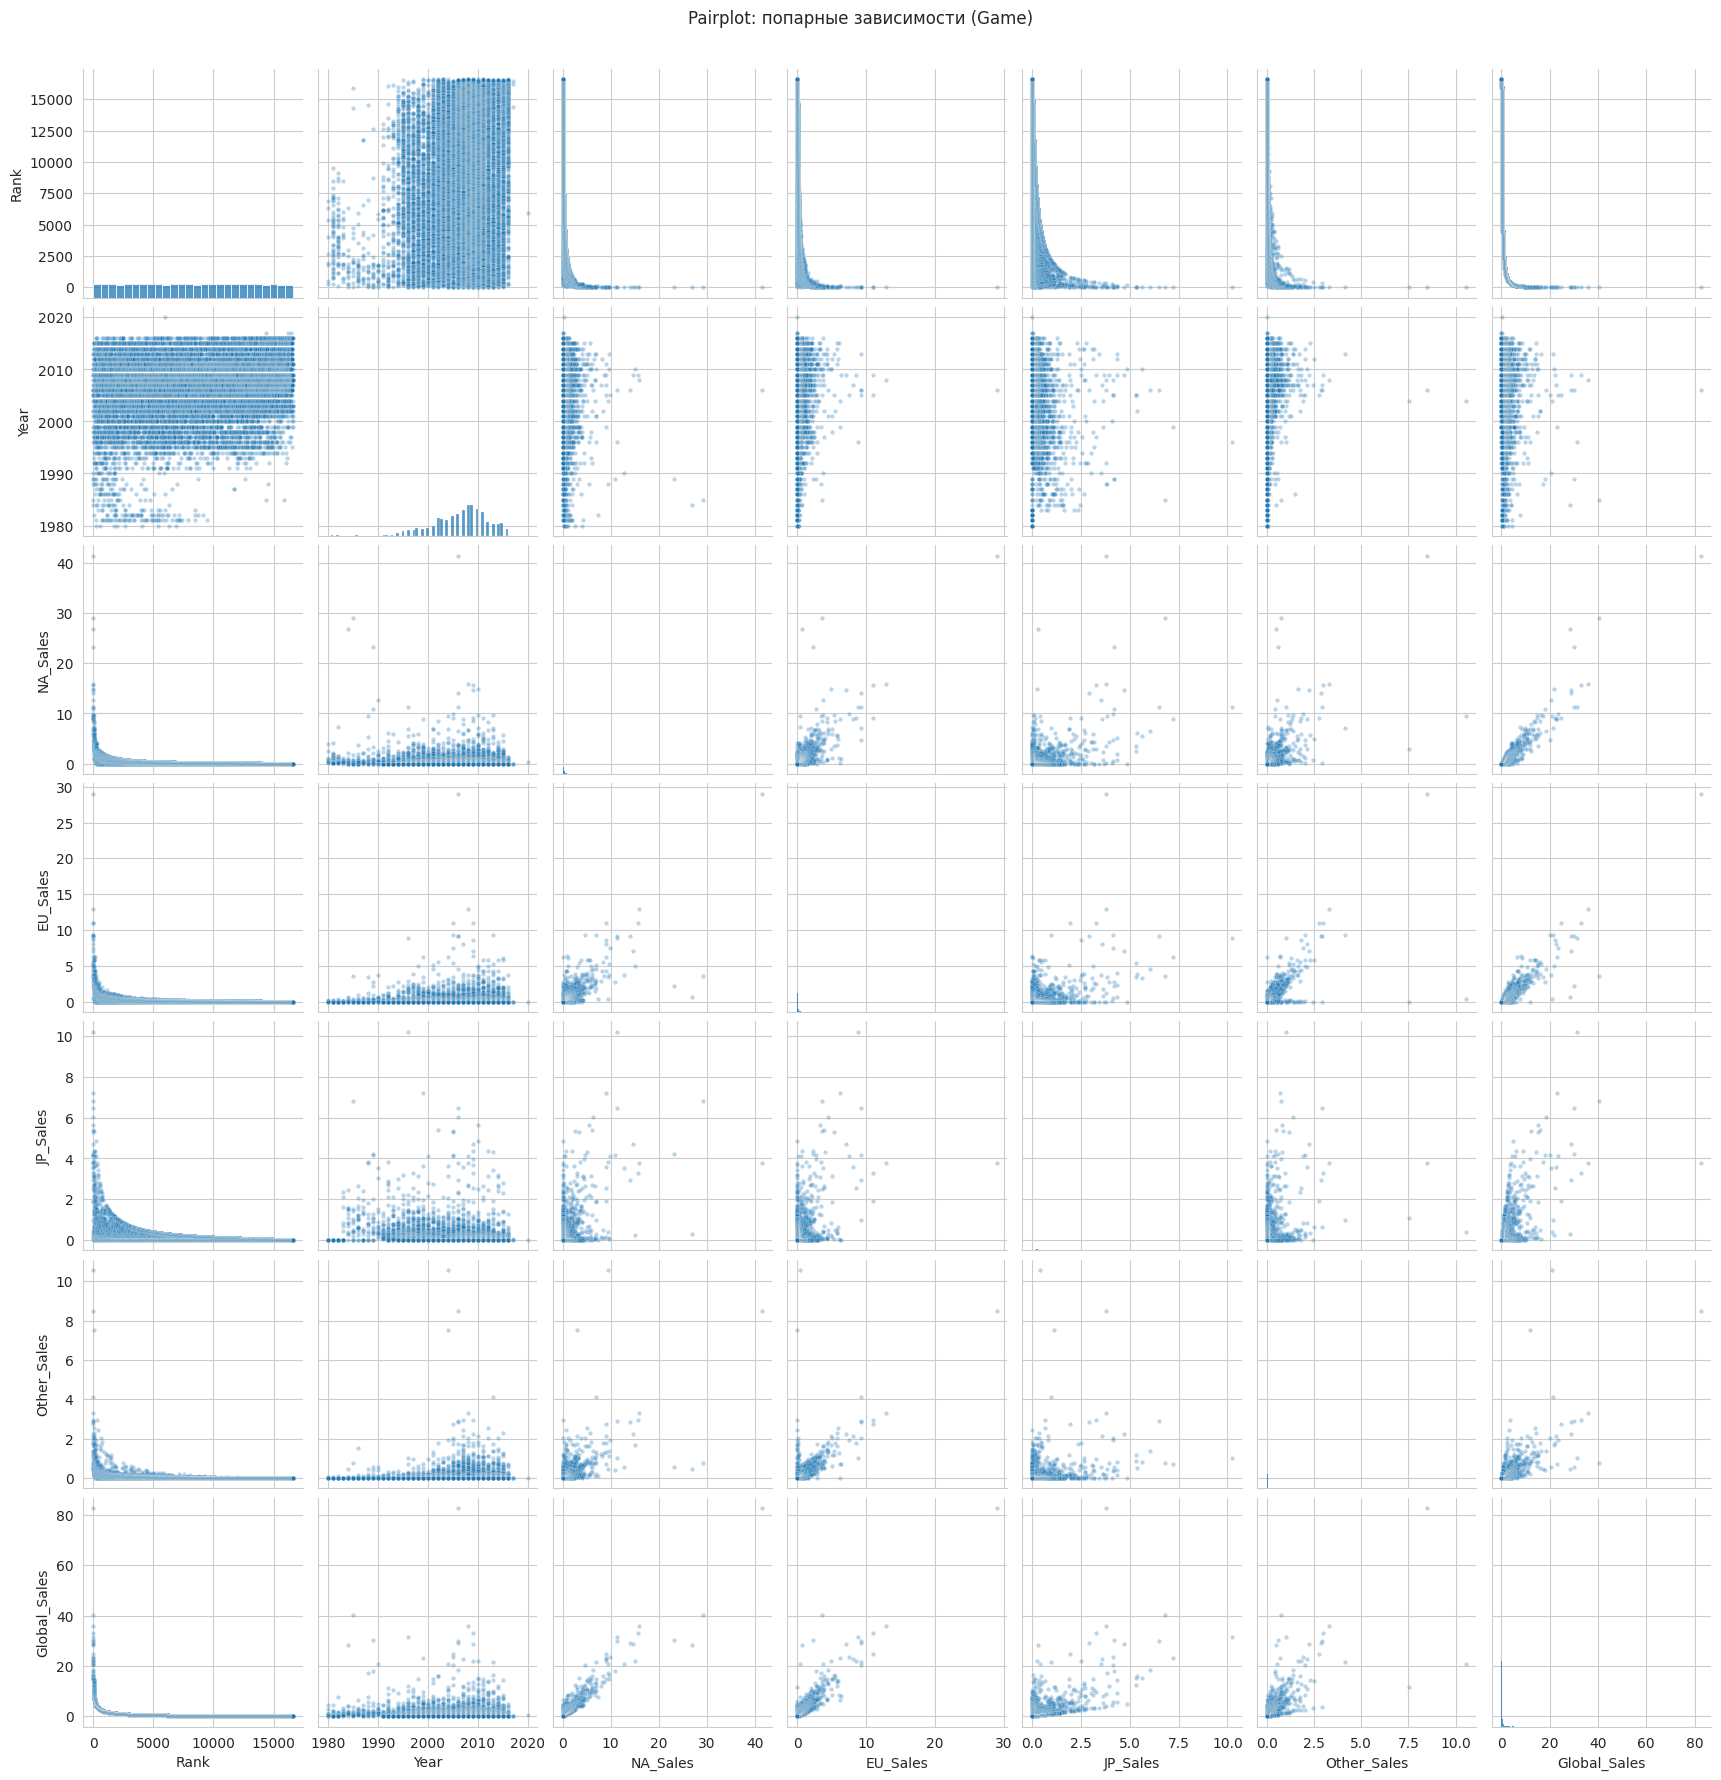

In [36]:
sns.pairplot(game[numeric_cols_B],
             diag_kind='hist',
             plot_kws={'alpha': 0.3, 's': 10})

plt.suptitle('Pairplot: попарные зависимости (Game)', y=1.02)
plt.show()